In [1]:
import pandas as pd

df = pd.read_parquet(r"C:\Users\z3553082\OneDrive - UNSW\Documents\CICCADA - Data\Ausgrid\ausgrid_pv_combined.parquet")

In [2]:
df

,serial,MeasureTime,Vphase,Volts,Curr,ReactPow,ActivePow,month,source_file
0,810813941,2025-04-02 09:40:00,C,240.051147,1.719485,-193.997528,265.470276,2025-04,jm_unswnmisapr25
1,810813941,2025-04-02 09:40:00,B,233.825958,0.411921,-86.788360,35.736385,2025-04,jm_unswnmisapr25
2,810813941,2025-04-02 09:40:00,A,235.732666,2.649141,-112.314354,607.518555,2025-04,jm_unswnmisapr25
3,810813941,2025-04-02 09:45:00,C,239.834700,1.761055,-193.997528,270.575500,2025-04,jm_unswnmisapr25
4,810813941,2025-04-02 09:45:00,A,234.557724,2.399721,-91.893560,551.361400,2025-04,jm_unswnmisapr25
...,...,...,...,...,...,...,...,...,...
303647628,811513156,2024-09-30 23:45:00,A,242.277374,10.687262,342.048248,-2557.704000,2024-09,jm_unswnmissep24
303647629,811513156,2024-09-30 23:50:00,B,240.514938,0.000000,0.000000,0.000000,2024-09,jm_unswnmissep24
303647630,811513156,2024-09-30 23:50:00,A,240.514938,10.849764,-76.577970,-2588.335450,2024-09,jm_unswnmissep24
303647631,811513156,2024-09-30 23:55:00,A,240.112976,11.522441,51.051980,-2751.701660,2024-09,jm_unswnmissep24


In [3]:
SERIAL = 810584444
# SERIAL = 811513156
SERIAL = 811280075

In [4]:
df_filtered = df[df['serial']==SERIAL].groupby(['serial', 'MeasureTime']).agg({
    'Volts': 'mean',
    'ReactPow': 'sum',
    'ActivePow': 'sum',
    'Curr': 'sum'
}).reset_index()

df_filtered

,serial,MeasureTime,Volts,ReactPow,ActivePow,Curr
0,811280075,2024-08-01 00:00:00,240.178253,-275.680684,-479.888630,5.653517
1,811280075,2024-08-01 00:05:00,241.095540,-209.313114,-730.043319,6.722999
2,811280075,2024-08-01 00:10:00,240.714197,250.154702,-964.882403,7.841609
3,811280075,2024-08-01 00:15:00,242.352948,250.154684,1271.194120,15.244843
4,811280075,2024-08-01 00:20:00,240.614568,-153.155936,1490.717775,13.842802
...,...,...,...,...,...,...
104971,811280075,2025-07-31 23:35:00,237.584426,-270.575492,-377.784650,3.318040
104972,811280075,2025-07-31 23:40:00,237.295843,-275.680682,-342.048255,3.299144
104973,811280075,2025-07-31 23:45:00,237.910797,-148.050739,-464.573010,3.794205
104974,811280075,2025-07-31 23:50:00,238.676932,-204.207916,-484.993760,4.020950


In [5]:
df_filtered['ApparentPow'] = ((df_filtered['ReactPow'] ** 2) + (df_filtered['ActivePow'] ** 2)) ** 0.5
df_filtered

,serial,MeasureTime,Volts,ReactPow,ActivePow,Curr,ApparentPow
0,811280075,2024-08-01 00:00:00,240.178253,-275.680684,-479.888630,5.653517,553.437383
1,811280075,2024-08-01 00:05:00,241.095540,-209.313114,-730.043319,6.722999,759.457193
2,811280075,2024-08-01 00:10:00,240.714197,250.154702,-964.882403,7.841609,996.782537
3,811280075,2024-08-01 00:15:00,242.352948,250.154684,1271.194120,15.244843,1295.573949
4,811280075,2024-08-01 00:20:00,240.614568,-153.155936,1490.717775,13.842802,1498.564722
...,...,...,...,...,...,...,...
104971,811280075,2025-07-31 23:35:00,237.584426,-270.575492,-377.784650,3.318040,464.685204
104972,811280075,2025-07-31 23:40:00,237.295843,-275.680682,-342.048255,3.299144,439.314064
104973,811280075,2025-07-31 23:45:00,237.910797,-148.050739,-464.573010,3.794205,487.593174
104974,811280075,2025-07-31 23:50:00,238.676932,-204.207916,-484.993760,4.020950,526.231717


In [6]:
# Choose a random 7-day window from the full-year data using MeasureTime
possible_starts = pd.date_range(
    start=df_filtered['MeasureTime'].min().normalize(),
    end=df_filtered['MeasureTime'].max().normalize() - pd.Timedelta(days=7),
    freq='D'
)

random_start = possible_starts.to_series().sample(1).iloc[0]

df_random_week = df_filtered[
    (df_filtered['MeasureTime'] >= random_start) &
    (df_filtered['MeasureTime'] < random_start + pd.Timedelta(days=7))
].copy()

df_random_week

,serial,MeasureTime,Volts,ReactPow,ActivePow,Curr,ApparentPow
51552,811280075,2025-01-27 00:00:00,244.833405,1291.615096,-2833.384806,14.481467,3113.894509
51553,811280075,2025-01-27 00:05:00,244.692551,1485.612556,-2940.594010,14.957632,3294.561852
51554,811280075,2025-01-27 00:10:00,244.458931,1633.663372,-2925.278240,15.161704,3350.538583
51555,811280075,2025-01-27 00:15:00,244.534516,1654.084152,-3012.066794,16.102696,3436.355737
51556,811280075,2025-01-27 00:20:00,244.417703,1654.084080,-3022.277208,16.242522,3445.308936
...,...,...,...,...,...,...,...
53563,811280075,2025-02-02 23:35:00,245.606399,1087.407168,-1781.714019,10.910228,2087.333034
53564,811280075,2025-02-02 23:40:00,246.255717,1138.459168,-1740.872490,10.895112,2080.078437
53565,811280075,2025-02-02 23:45:00,246.509944,1393.719058,-2128.867422,12.841343,2544.509641
53566,811280075,2025-02-02 23:50:00,246.650808,1470.297006,-2031.868859,12.727971,2508.039941


<Axes: title={'center': 'Power over Time for Serial 810584444 (Random Week Starting 2025-01-27)'}, xlabel='MeasureTime'>

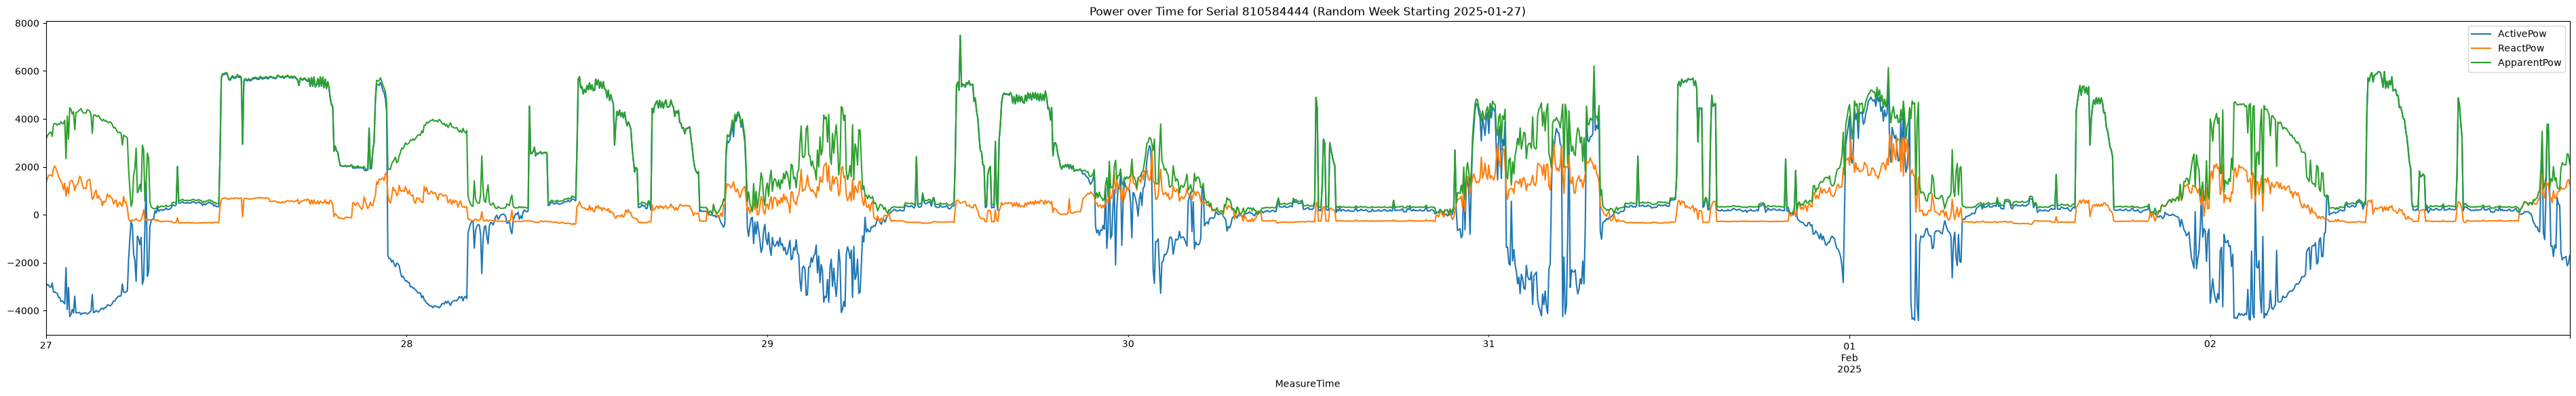

In [7]:
df_random_week.plot(x='MeasureTime', y=['ActivePow', 'ReactPow', 'ApparentPow'], figsize=(48, 6), kind='line', title=f'Power over Time for Serial 810584444 (Random Week Starting {random_start.date()})')

In [8]:
middle_day = random_start + pd.Timedelta(days=3)  # 4th day of the 7-day window

df_middle_day = df_random_week[
    (df_random_week['MeasureTime'] >= middle_day) &
    (df_random_week['MeasureTime'] < middle_day + pd.Timedelta(days=1))
].copy()

df_middle_day

,serial,MeasureTime,Volts,ReactPow,ActivePow,Curr,ApparentPow
52416,811280075,2025-01-30 00:00:00,243.273671,1036.355159,1092.512372,15.777694,1505.860318
52417,811280075,2025-01-30 00:05:00,242.665583,1184.405940,1046.565553,16.828282,1580.543225
52418,811280075,2025-01-30 00:10:00,244.056977,1557.085338,500.309492,19.035270,1635.489021
52419,811280075,2025-01-30 00:15:00,246.946263,2113.551961,-959.777392,25.066694,2321.265718
52420,811280075,2025-01-30 00:20:00,245.561737,1342.667048,934.251080,17.629448,1635.719989
...,...,...,...,...,...,...,...
52699,811280075,2025-01-30 23:35:00,242.988523,1536.664535,4053.527368,31.188819,4335.022724
52700,811280075,2025-01-30 23:40:00,240.748556,1725.556838,3711.479116,32.613534,4092.996901
52701,811280075,2025-01-30 23:45:00,242.603744,2164.603899,3313.273261,35.410061,3957.687423
52702,811280075,2025-01-30 23:50:00,244.345562,1659.189358,4033.106080,31.222831,4361.061107


<Axes: title={'center': 'Power over Time for Serial 810584444 (Middle Day: 2025-01-30)'}, xlabel='MeasureTime'>

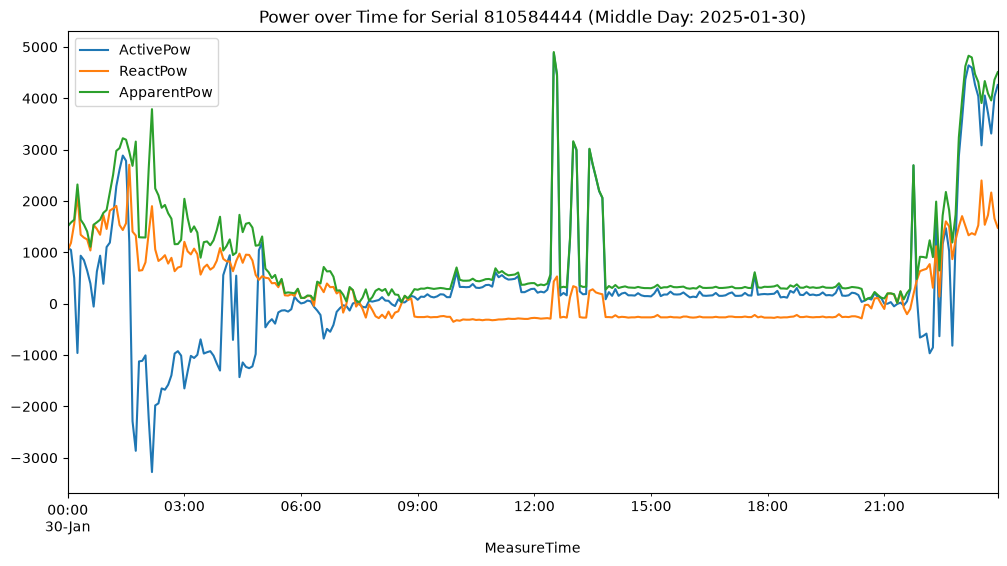

In [ ]:
# df_middle_day.plot(x='MeasureTime', y=['ActivePow', 'ReactPow', 'ApparentPow'], figsize=(12, 6), kind='line', title=f'Power over Time for Serial 810584444 (Middle Day: {middle_day.date()})')

In [10]:
df_middle_day_full = df[
    (df['MeasureTime'] >= middle_day) &
    (df['MeasureTime'] < middle_day + pd.Timedelta(days=1))
].copy()

df_middle_day_full

,serial,MeasureTime,Vphase,Volts,Curr,ReactPow,ActivePow,month,source_file
94230657,326214487,2025-01-30 00:00:00,A,241.215790,0.544189,-61.262375,96.998764,2025-01,jm_unswnmisjan25
94230658,326214487,2025-01-30 00:00:00,B,242.957600,0.997679,-188.892319,102.103958,2025-01,jm_unswnmisjan25
94230659,326214487,2025-01-30 00:00:00,C,241.205475,4.179672,234.839111,-964.882400,2025-01,jm_unswnmisjan25
94230660,326214487,2025-01-30 00:05:00,C,240.741684,3.729960,30.631187,-878.094055,2025-01,jm_unswnmisjan25
94230661,326214487,2025-01-30 00:05:00,A,240.484024,0.547968,-66.367570,96.998764,2025-01,jm_unswnmisjan25
...,...,...,...,...,...,...,...,...,...
119952581,811513156,2025-01-30 23:45:00,B,236.639648,0.000000,0.000000,0.000000,2025-01,jm_unswnmisjan25
119952582,811513156,2025-01-30 23:50:00,A,236.196472,1.398263,5.105198,-275.680700,2025-01,jm_unswnmisjan25
119952583,811513156,2025-01-30 23:50:00,B,236.196472,0.000000,0.000000,0.000000,2025-01,jm_unswnmisjan25
119952584,811513156,2025-01-30 23:55:00,A,235.980026,1.462507,10.210396,-270.575500,2025-01,jm_unswnmisjan25


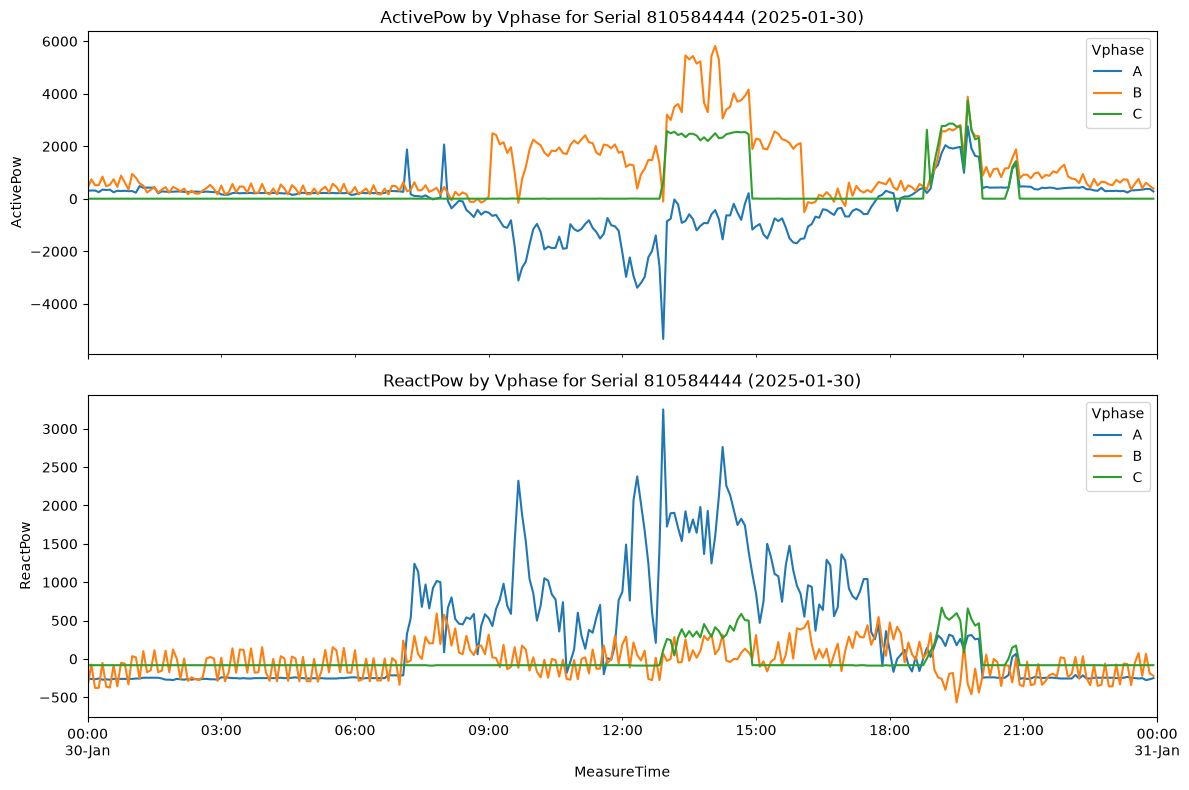

In [11]:
import matplotlib.pyplot as plt

# Convert to Australia/Sydney time and filter to one local day (00:00 -> midnight)
df_oneserial = df.copy()
df_oneserial['MeasureTime'] = pd.to_datetime(df_oneserial['MeasureTime'], utc=True).dt.tz_convert('Australia/Sydney')

day_start = pd.Timestamp(middle_day.date(), tz='Australia/Sydney')
day_end = day_start + pd.Timedelta(days=1)

df_oneserial = df_oneserial[
    (df_oneserial['serial'] == 810584444) &
    (df_oneserial['MeasureTime'] >= day_start) &
    (df_oneserial['MeasureTime'] < day_end)
].copy()

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for ax, metric in zip(axes, ['ActivePow', 'ReactPow']):
    (
        df_oneserial
        .pivot_table(index='MeasureTime', columns='Vphase', values=metric, aggfunc='mean')
        .sort_index()
        .plot(ax=ax)
    )
    ax.set_title(f'{metric} by Vphase for Serial 810584444 ({day_start.date()})')
    ax.set_ylabel(metric)
    ax.set_xlim(day_start, day_end)

plt.tight_layout()

In [12]:
df_oneserial['ApparentPow'] = ((df_oneserial['ReactPow'] ** 2) + (df_oneserial['ActivePow'] ** 2)) ** 0.5
df_oneserial

,serial,MeasureTime,Vphase,Volts,Curr,ReactPow,ActivePow,month,source_file,ApparentPow
99089781,810584444,2025-01-30 00:00:00+11:00,A,244.359300,1.836637,-260.365082,311.417084,2025-01,jm_unswnmisjan25,405.919421
99089782,810584444,2025-01-30 00:00:00+11:00,B,243.782135,2.309023,-357.363861,398.205444,2025-01,jm_unswnmisjan25,535.048133
99089783,810584444,2025-01-30 00:00:00+11:00,C,245.091064,0.343897,-81.683170,5.105198,2025-01,jm_unswnmisjan25,81.842552
99089784,810584444,2025-01-30 00:05:00+11:00,C,244.854019,0.340118,-81.683170,5.105198,2025-01,jm_unswnmisjan25,81.842552
99089785,810584444,2025-01-30 00:05:00+11:00,B,244.163483,3.132864,-71.472770,740.253700,2025-01,jm_unswnmisjan25,743.696105
...,...,...,...,...,...,...,...,...,...,...
99090640,810584444,2025-01-30 23:50:00+11:00,A,243.936737,2.112510,-265.470276,377.784637,2025-01,jm_unswnmisjan25,461.731198
99090641,810584444,2025-01-30 23:50:00+11:00,B,242.205215,2.297686,-188.892319,495.204200,2025-01,jm_unswnmisjan25,530.007083
99090642,810584444,2025-01-30 23:55:00+11:00,B,243.204956,1.965126,-219.523514,387.995056,2025-01,jm_unswnmisjan25,445.792257
99090643,810584444,2025-01-30 23:55:00+11:00,C,243.266800,0.343897,-81.683170,5.105198,2025-01,jm_unswnmisjan25,81.842552


In [13]:
df_oneserial

,serial,MeasureTime,Vphase,Volts,Curr,ReactPow,ActivePow,month,source_file,ApparentPow
99089781,810584444,2025-01-30 00:00:00+11:00,A,244.359300,1.836637,-260.365082,311.417084,2025-01,jm_unswnmisjan25,405.919421
99089782,810584444,2025-01-30 00:00:00+11:00,B,243.782135,2.309023,-357.363861,398.205444,2025-01,jm_unswnmisjan25,535.048133
99089783,810584444,2025-01-30 00:00:00+11:00,C,245.091064,0.343897,-81.683170,5.105198,2025-01,jm_unswnmisjan25,81.842552
99089784,810584444,2025-01-30 00:05:00+11:00,C,244.854019,0.340118,-81.683170,5.105198,2025-01,jm_unswnmisjan25,81.842552
99089785,810584444,2025-01-30 00:05:00+11:00,B,244.163483,3.132864,-71.472770,740.253700,2025-01,jm_unswnmisjan25,743.696105
...,...,...,...,...,...,...,...,...,...,...
99090640,810584444,2025-01-30 23:50:00+11:00,A,243.936737,2.112510,-265.470276,377.784637,2025-01,jm_unswnmisjan25,461.731198
99090641,810584444,2025-01-30 23:50:00+11:00,B,242.205215,2.297686,-188.892319,495.204200,2025-01,jm_unswnmisjan25,530.007083
99090642,810584444,2025-01-30 23:55:00+11:00,B,243.204956,1.965126,-219.523514,387.995056,2025-01,jm_unswnmisjan25,445.792257
99090643,810584444,2025-01-30 23:55:00+11:00,C,243.266800,0.343897,-81.683170,5.105198,2025-01,jm_unswnmisjan25,81.842552


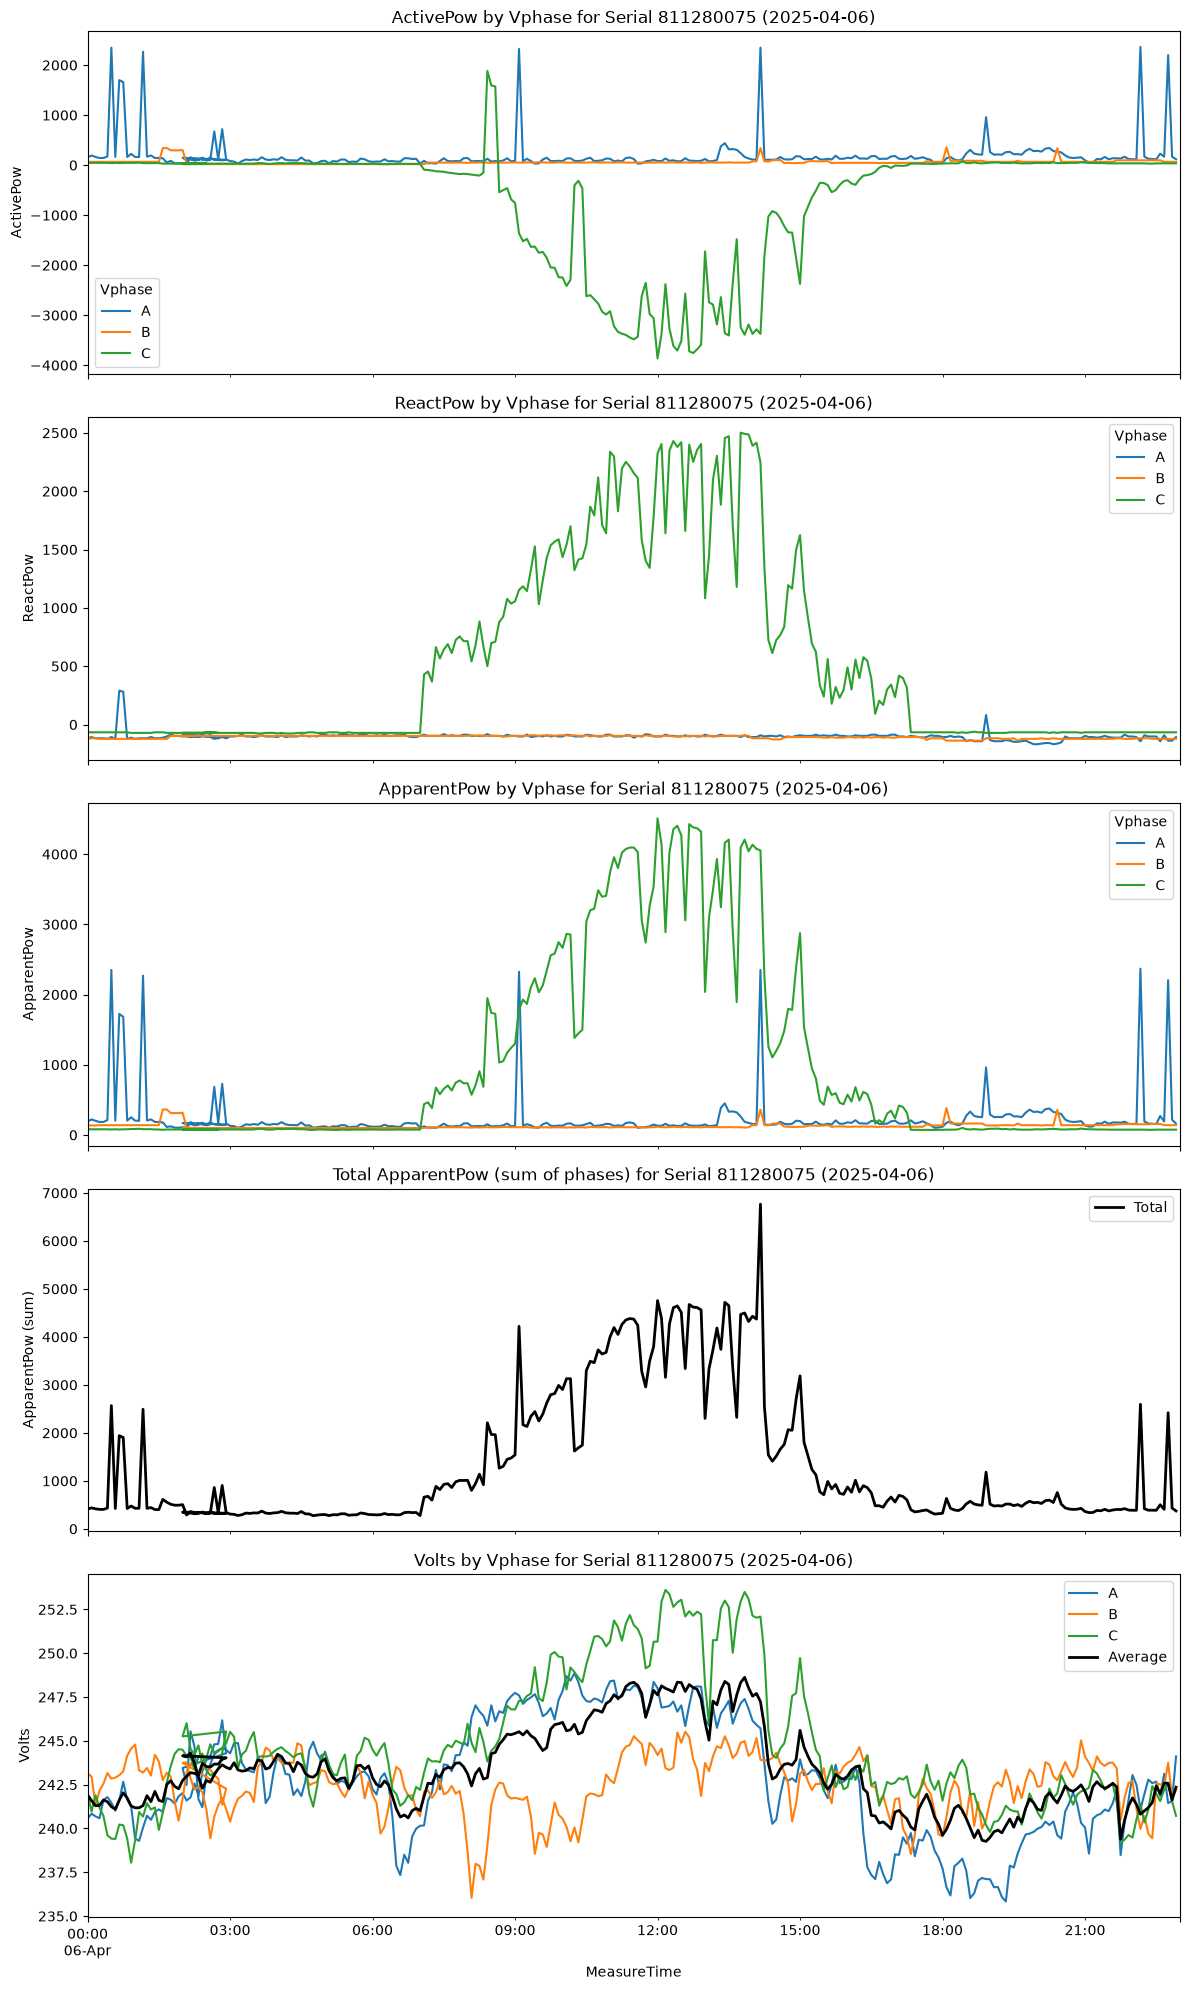

In [14]:
day_start = pd.Timestamp('2025-04-06', tz='Australia/Sydney')  # 06-04-2025 = 6 Apr 2025
day_end = day_start + pd.Timedelta(days=1)

df_oneserial = df.copy()
df_oneserial['MeasureTime'] = pd.to_datetime(df_oneserial['MeasureTime'], utc=True).dt.tz_convert('Australia/Sydney')
df_oneserial['ApparentPow'] = ((df_oneserial['ReactPow'] ** 2) + (df_oneserial['ActivePow'] ** 2)) ** 0.5

df_oneserial = df_oneserial[
    (df_oneserial['serial'] == SERIAL) &
    (df_oneserial['MeasureTime'] >= day_start) &
    (df_oneserial['MeasureTime'] < day_end)
].copy()

fig, axes = plt.subplots(5, 1, figsize=(12, 20), sharex=True)

phases = sorted(df_oneserial['Vphase'].unique())
palette = plt.cm.tab10.colors
phase_colors = {phase: palette[i] for i, phase in enumerate(phases)}

power_metrics = ['ActivePow', 'ReactPow', 'ApparentPow']

for ax, metric in zip(axes[:3], power_metrics):
    pivoted = (
        df_oneserial
        .pivot_table(index='MeasureTime', columns='Vphase', values=metric, aggfunc='mean')
        .sort_index()
    )
    pivoted.plot(ax=ax, color=[phase_colors[c] for c in pivoted.columns])
    ax.set_title(f'{metric} by Vphase for Serial {SERIAL} ({day_start.date()})')
    ax.set_ylabel(metric)
    ax.set_xlim(day_start, day_end)

total_apparent = (
    df_oneserial
    .pivot_table(index='MeasureTime', columns='Vphase', values='ApparentPow', aggfunc='mean')
    .sort_index()
    .sum(axis=1)
)
total_apparent.plot(ax=axes[3], color='black', linewidth=2, label='Total')
axes[3].set_title(f'Total ApparentPow (sum of phases) for Serial {SERIAL} ({day_start.date()})')
axes[3].set_ylabel('ApparentPow (sum)')
axes[3].set_xlim(day_start, day_end)
axes[3].legend()

pivoted_volts = (
    df_oneserial
    .pivot_table(index='MeasureTime', columns='Vphase', values='Volts', aggfunc='mean')
    .sort_index()
)
pivoted_volts.plot(ax=axes[4], color=[phase_colors[c] for c in pivoted_volts.columns])
pivoted_volts.mean(axis=1).plot(ax=axes[4], color='black', linewidth=2, label='Average')
axes[4].set_title(f'Volts by Vphase for Serial {SERIAL} ({day_start.date()})')
axes[4].set_ylabel('Volts')
axes[4].set_xlim(day_start, day_end)
axes[4].legend()

plt.tight_layout()